In [2]:
# ─────────────────────────────────────────────
# CELL 1 — Load Silver Master Table
# ─────────────────────────────────────────────

df = spark.sql("""
    SELECT * FROM TechNova_HR_Lakehouse.dbo.silver_master_employees
""").toPandas()

print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nAttrition distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%")

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 5, Finished, Available, Finished, False)

✅ Data loaded: 4000 rows, 35 columns

Attrition distribution:
Attrition
No     2335
Yes    1665
Name: count, dtype: int64

Attrition rate: 41.6%


In [3]:
# ─────────────────────────────────────────────
# CELL 2 — Feature Engineering + Preprocessing
# Convert categorical → numerical
# Select relevant features
# Scale numerical features
# ─────────────────────────────────────────────

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Step 1: Encode categorical columns ───────
# OverTime: Yes=1, No=0
df['OverTime_Encoded'] = (df['OverTime'] == 'Yes').astype(int)

# MaritalStatus: Single=0, Married=1, Divorced=2
marital_map = {'Single': 0, 'Married': 1, 'Divorced': 2}
df['MaritalStatus_Encoded'] = df['MaritalStatus'].map(marital_map)

# BusinessTravelFrequency: Non-Travel=0, Rarely=1, Frequently=2
travel_map = {
    'Non-Travel': 0,
    'Travel_Rarely': 1,
    'Travel_Frequently': 2
}
df['BusinessTravel_Encoded'] = df['BusinessTravelFrequency'].map(travel_map)

# ── Step 2: Target variable ───────────────────
# Attrition: Yes=1, No=0
df['Target'] = (df['Attrition'] == 'Yes').astype(int)

# ── Step 3: Select final feature columns ──────
FEATURES = [
    # Personal
    'Age',
    'MaritalStatus_Encoded',
    'DistanceFromHome',
    'NumCompaniesWorked',

    # Job
    'MonthlyIncome',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'OverTime_Encoded',
    'BusinessTravel_Encoded',

    # Satisfaction
    'JobSatisfaction',
    'WorkLifeBalance',
    'RelationshipSatisfaction',
    'EnvironmentSatisfaction',
    'JobInvolvement',

    # Attendance
    'AvgHoursPerDay',
    'AbsentDaysLastYear'
]

TARGET = 'Target'

# ── Step 4: Extract X and y ───────────────────
X = df[FEATURES]
y = df[TARGET]

print(f"✅ Features prepared")
print(f"   Feature matrix shape : {X.shape}")
print(f"   Target variable shape: {y.shape}")
print(f"   Features used        : {len(FEATURES)}")
print(f"\nFeature list:")
for i, f in enumerate(FEATURES, 1):
    print(f"   {i:2d}. {f}")

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 6, Finished, Available, Finished, False)

✅ Features prepared
   Feature matrix shape : (4000, 19)
   Target variable shape: (4000,)
   Features used        : 19

Feature list:
    1. Age
    2. MaritalStatus_Encoded
    3. DistanceFromHome
    4. NumCompaniesWorked
    5. MonthlyIncome
    6. YearsAtCompany
    7. YearsInCurrentRole
    8. YearsSinceLastPromotion
    9. TotalWorkingYears
   10. TrainingTimesLastYear
   11. OverTime_Encoded
   12. BusinessTravel_Encoded
   13. JobSatisfaction
   14. WorkLifeBalance
   15. RelationshipSatisfaction
   16. EnvironmentSatisfaction
   17. JobInvolvement
   18. AvgHoursPerDay
   19. AbsentDaysLastYear


In [4]:
# ─────────────────────────────────────────────
# CELL 3 — Train/Test Split + Feature Scaling
# ─────────────────────────────────────────────

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Step 1: Train/Test Split ──────────────────
# 80% train, 20% test
# random_state=42 ensures reproducibility
# stratify=y ensures both splits have same 
# attrition ratio (important for imbalanced data)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ← maintains 41/59 ratio in both splits
)

print(f"✅ Data split complete")
print(f"   Training set : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test set     : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nAttrition ratio check:")
print(f"   Train — Yes: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"   Test  — Yes: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

# ── Step 2: Feature Scaling ───────────────────
# StandardScaler converts all features to 
# same scale: mean=0, standard deviation=1
# 
# Why needed?
# MonthlyIncome: 25,000 - 300,000
# JobSatisfaction: 1 - 4
# Without scaling → Income dominates all calculations
# With scaling → all features contribute equally

scaler = StandardScaler()

# CRITICAL RULE:
# Fit scaler ONLY on training data
# Transform both train AND test using train's scale
# Never fit on test data — that would be data leakage

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)    # ← transform only, not fit

print(f"\n✅ Feature scaling complete")
print(f"   Method: StandardScaler (mean=0, std=1)")
print(f"   Example — MonthlyIncome before scaling:")
print(f"   Mean: {X_train['MonthlyIncome'].mean():,.0f}")
print(f"   After scaling mean: {X_train_scaled[:,4].mean():.4f}")

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 7, Finished, Available, Finished, False)

✅ Data split complete
   Training set : 3200 rows (80%)
   Test set     : 800 rows (20%)

Attrition ratio check:
   Train — Yes: 1332 (41.6%)
   Test  — Yes: 333 (41.6%)

✅ Feature scaling complete
   Method: StandardScaler (mean=0, std=1)
   Example — MonthlyIncome before scaling:
   Mean: 76,124
   After scaling mean: 0.0000


StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 8, Finished, Available, Finished, False)

Calculating WCSS for K=2 to K=10...
────────────────────────────────────────


K= 2 → WCSS: 54,018


K= 3 → WCSS: 51,846


K= 4 → WCSS: 50,083


...

K= 6 → WCSS: 48,360


K= 7 → WCSS: 47,533


K= 8 → WCSS: 46,813


K= 9 → WCSS: 46,262


K=10 → WCSS: 45,736


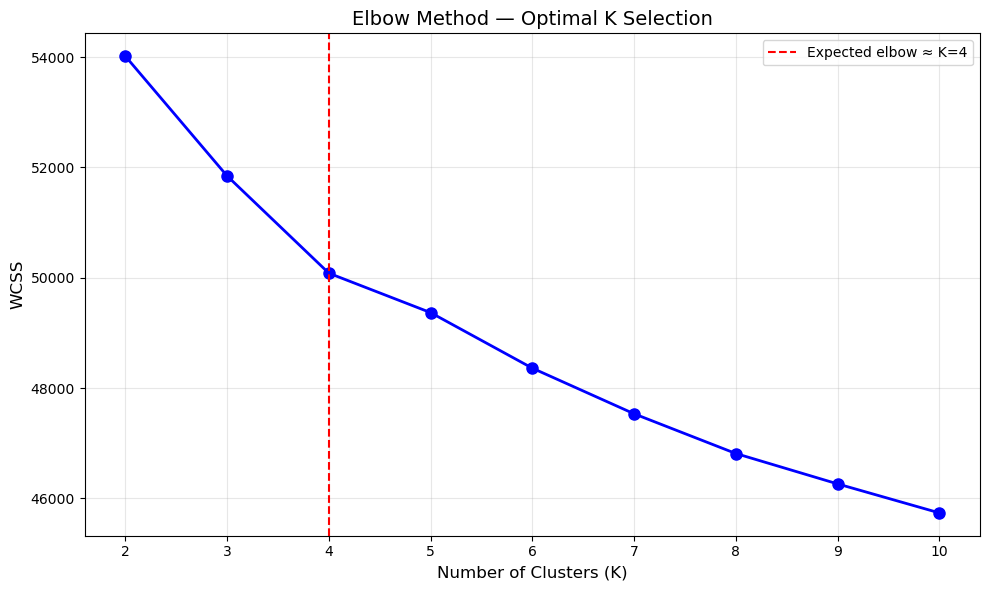


✅ Elbow curve generated
Look at the chart — where does the curve flatten?
That K value is our optimal cluster count


In [5]:
# ─────────────────────────────────────────────
# CELL 4 — K-Means: Elbow Method
# Find optimal number of clusters
# ─────────────────────────────────────────────

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
K_range = range(2, 11)  # Test K from 2 to 10

print("Calculating WCSS for K=2 to K=10...")
print("─" * 40)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10        # Run 10 times, pick best result
    )
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS
    print(f"K={k:2d} → WCSS: {kmeans.inertia_:,.0f}")

# ── Plot Elbow Curve ──────────────────────────
plt.figure(figsize=(10, 6))
plt.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.title('Elbow Method — Optimal K Selection', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Highlight elbow point
plt.axvline(x=4, color='red', linestyle='--', 
            label='Expected elbow ≈ K=4')
plt.legend()
plt.tight_layout()
plt.savefig('/tmp/elbow_curve.png', dpi=150)
plt.show()

print("\n✅ Elbow curve generated")
print("Look at the chart — where does the curve flatten?")
print("That K value is our optimal cluster count")

In [6]:
# ─────────────────────────────────────────────
# CELL 5 — K-Means Final Model (K=4)
# Assign each employee to a cluster
# ─────────────────────────────────────────────

# Train final K-Means model with optimal K=4
kmeans_final = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit on training data, predict clusters for ALL employees
# We use full X (not just train) since K-Means doesn't need 
# train/test split — it's unsupervised, just grouping
X_full_scaled = scaler.transform(X)  # scale full dataset using train scaler

df['Cluster'] = kmeans_final.fit_predict(X_full_scaled)

print("✅ K-Means clustering complete")
print(f"\nEmployees per cluster:")
print(df['Cluster'].value_counts().sort_index())

# ── Profile each cluster ──────────────────────
print("\n" + "="*60)
print("CLUSTER PROFILES — Average values per cluster")
print("="*60)

cluster_profile = df.groupby('Cluster')[FEATURES + ['Target']].mean()
print(cluster_profile.round(2))

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 9, Finished, Available, Finished, False)

✅ K-Means clustering complete

Employees per cluster:
Cluster
0     544
1    1183
2    1162
3    1111
Name: count, dtype: int64

CLUSTER PROFILES — Average values per cluster
           Age  MaritalStatus_Encoded  DistanceFromHome  NumCompaniesWorked  \
Cluster                                                                       
0        40.95                   1.06             30.56                4.37   
1        39.34                   1.02             29.98                4.53   
2        40.26                   1.00             31.68                4.66   
3        39.59                   0.98             29.10                4.54   

         MonthlyIncome  YearsAtCompany  YearsInCurrentRole  \
Cluster                                                      
0            164825.09           12.73                2.28   
1             53263.12            2.35                1.20   
2             50527.32            2.15                1.11   
3             83646.15            6.25  

In [7]:
# ─────────────────────────────────────────────
# CELL 6 — Name Clusters Based On Profile
# ─────────────────────────────────────────────

cluster_names = {
    0: 'Senior Veterans',
    1: 'Disengaged Newcomers',
    2: 'Content Newcomers',
    3: 'Stagnant Mid-Career'
}

df['ClusterName'] = df['Cluster'].map(cluster_names)

print("✅ Clusters named")
print(df['ClusterName'].value_counts())

# Quick visual check — attrition rate per cluster
print("\nAttrition Rate by Cluster:")
print(df.groupby('ClusterName')['Target'].mean().sort_values(ascending=False))

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 10, Finished, Available, Finished, False)

✅ Clusters named
ClusterName
Disengaged Newcomers    1183
Content Newcomers       1162
Stagnant Mid-Career     1111
Senior Veterans          544
Name: count, dtype: int64

Attrition Rate by Cluster:
ClusterName
Stagnant Mid-Career     0.464446
Senior Veterans         0.433824
Disengaged Newcomers    0.399831
Content Newcomers       0.378657
Name: Target, dtype: float64


In [8]:
# ─────────────────────────────────────────────
# CELL 7 — Decision Tree Classifier
# ─────────────────────────────────────────────

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, classification_report
)

# Train Decision Tree
# max_depth limits tree size — prevents overfitting
dt_model = DecisionTreeClassifier(
    max_depth=5,           # limit depth for interpretability
    min_samples_split=20,  # need at least 20 samples to split
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

# Predict on test set
y_pred_dt = dt_model.predict(X_test_scaled)

# ── Evaluate Model ────────────────────────────
print("="*50)
print("DECISION TREE — Performance Metrics")
print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_dt):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_dt):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_dt):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_dt))

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 11, Finished, Available, Finished, False)

DECISION TREE — Performance Metrics
Accuracy  : 0.579
Precision : 0.490
Recall    : 0.285
F1-Score  : 0.361

Confusion Matrix:
[[368  99]
 [238  95]]

Full Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.79      0.69       467
           1       0.49      0.29      0.36       333

    accuracy                           0.58       800
   macro avg       0.55      0.54      0.52       800
weighted avg       0.56      0.58      0.55       800



In [9]:
# ─────────────────────────────────────────────
# CELL 8 — Feature Importance from Decision Tree
# ─────────────────────────────────────────────

import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance — Decision Tree")
print("="*50)
print(feature_importance.to_string(index=False))

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 12, Finished, Available, Finished, False)

Feature Importance — Decision Tree
                 Feature  Importance
        DistanceFromHome    0.201317
 YearsSinceLastPromotion    0.168303
        OverTime_Encoded    0.135160
                     Age    0.119902
         WorkLifeBalance    0.113731
         JobSatisfaction    0.107524
      YearsInCurrentRole    0.037833
   TrainingTimesLastYear    0.029624
      NumCompaniesWorked    0.028658
      AbsentDaysLastYear    0.020007
          AvgHoursPerDay    0.019598
           MonthlyIncome    0.018344
       TotalWorkingYears    0.000000
   MaritalStatus_Encoded    0.000000
          YearsAtCompany    0.000000
  BusinessTravel_Encoded    0.000000
RelationshipSatisfaction    0.000000
 EnvironmentSatisfaction    0.000000
          JobInvolvement    0.000000


In [10]:
# ─────────────────────────────────────────────
# CELL 9 — Quick Validation: Distance vs Attrition
# ─────────────────────────────────────────────

print("Attrition Rate by Distance From Home (binned):")
df['DistanceBin'] = pd.cut(
    df['DistanceFromHome'], 
    bins=[0, 10, 20, 30, 40, 60],
    labels=['0-10km', '10-20km', '20-30km', '30-40km', '40-60km']
)
print(df.groupby('DistanceBin', observed=True)['Target'].agg(['mean', 'count']))

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 13, Finished, Available, Finished, False)

Attrition Rate by Distance From Home (binned):
                 mean  count
DistanceBin                 
0-10km       0.389134    681
10-20km      0.437318    686
20-30km      0.409366    662
30-40km      0.378671    647
40-60km      0.441088   1324


In [11]:
# ─────────────────────────────────────────────
# CELL 10 — Random Forest Classifier
# ─────────────────────────────────────────────

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,      # 200 trees in the forest
    max_depth=8,           # slightly deeper than single tree
    min_samples_split=15,
    random_state=42,
    class_weight='balanced'  # handles our 41/59 imbalance
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]  # probability scores

print("="*50)
print("RANDOM FOREST — Performance Metrics")
print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_rf):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf):.3f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf):.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nComparison — Decision Tree vs Random Forest:")
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Decision Tree': [0.579, 0.490, 0.285, 0.361],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})
print(comparison.to_string(index=False))

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 14, Finished, Available, Finished, False)

RANDOM FOREST — Performance Metrics
Accuracy  : 0.581
Precision : 0.497
Recall    : 0.498
F1-Score  : 0.498

Confusion Matrix:
[[299 168]
 [167 166]]

Comparison — Decision Tree vs Random Forest:
   Metric  Decision Tree  Random Forest
 Accuracy          0.579       0.581250
Precision          0.490       0.497006
   Recall          0.285       0.498498
 F1-Score          0.361       0.497751


In [12]:
# ─────────────────────────────────────────────
# CELL 11 — Random Forest Feature Importance
# ─────────────────────────────────────────────

rf_importance = pd.DataFrame({
    'Feature': FEATURES,
    'RF_Importance': rf_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print("Feature Importance — Random Forest (200 trees averaged)")
print("="*55)
print(rf_importance.to_string(index=False))

# Compare with Decision Tree
print("\n" + "="*55)
print("COMPARISON — Decision Tree vs Random Forest")
print("="*55)
comparison_importance = pd.DataFrame({
    'Feature': FEATURES,
    'Decision_Tree': dt_model.feature_importances_,
    'Random_Forest': rf_model.feature_importances_
}).sort_values('Random_Forest', ascending=False)
print(comparison_importance.to_string(index=False))

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 15, Finished, Available, Finished, False)

Feature Importance — Random Forest (200 trees averaged)
                 Feature  RF_Importance
           MonthlyIncome       0.102545
        DistanceFromHome       0.092196
                     Age       0.083822
          AvgHoursPerDay       0.081706
 YearsSinceLastPromotion       0.075543
       TotalWorkingYears       0.063390
      AbsentDaysLastYear       0.063180
      NumCompaniesWorked       0.057366
         JobSatisfaction       0.051208
         WorkLifeBalance       0.051155
          YearsAtCompany       0.049841
        OverTime_Encoded       0.043889
   TrainingTimesLastYear       0.039282
      YearsInCurrentRole       0.030251
          JobInvolvement       0.027889
RelationshipSatisfaction       0.025976
 EnvironmentSatisfaction       0.025626
   MaritalStatus_Encoded       0.018150
  BusinessTravel_Encoded       0.016984

COMPARISON — Decision Tree vs Random Forest
                 Feature  Decision_Tree  Random_Forest
           MonthlyIncome       0.018344     

In [13]:
# ─────────────────────────────────────────────
# CELL 12 — Generate Predictions For ALL Employees
# Save Random Forest probability scores
# ─────────────────────────────────────────────

# Get RF probability predictions for ALL 4000 employees
# (not just test set) — needed for Power BI dashboard

X_full_scaled_final = scaler.transform(X)
df['ML_Attrition_Probability'] = rf_model.predict_proba(X_full_scaled_final)[:, 1]
df['ML_Predicted_Attrition'] = rf_model.predict(X_full_scaled_final)

# Convert probability to percentage for readability
df['ML_Risk_Score_Pct'] = (df['ML_Attrition_Probability'] * 100).round(1)

print("✅ Predictions generated for all 4,000 employees")
print(f"\nSample predictions:")
print(df[['EmployeeID', 'Name', 'Attrition', 
          'ML_Risk_Score_Pct', 'ML_Predicted_Attrition']].head(10))

print(f"\nML Predicted Attrition Rate: {df['ML_Predicted_Attrition'].mean()*100:.1f}%")
print(f"Actual Attrition Rate      : {df['Target'].mean()*100:.1f}%")

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 17, Finished, Available, Finished, False)

✅ Predictions generated for all 4,000 employees

Sample predictions:
   EmployeeID              Name Attrition  ML_Risk_Score_Pct  \
0        1001  Chakradev Oommen        No               45.1   
1        1002    Chandran Batta        No               52.4   
2        1003        Qarin Mand        No               39.5   
3        1004     Harini Pingle       Yes               46.9   
4        1005    Theodore Madan        No               37.9   
5        1006         Tanvi Som        No               40.9   
6        1007   Ikshita Thakkar        No               33.1   
7        1008    Aadhya Narayan       Yes               69.1   
8        1009      Peter Talwar        No               35.5   
9        1010      Samuel Mutti       Yes               38.9   

   ML_Predicted_Attrition  
0                       0  
1                       1  
2                       0  
3                       0  
4                       0  
5                       0  
6                       0  
7 

In [14]:
# ─────────────────────────────────────────────
# CELL 13 — Save ML Results Back To Lakehouse
# This table will be source for Gold layer 
# AI Risk Card view in Power BI
# ─────────────────────────────────────────────

# Select relevant columns for ML results table
ml_results = df[[
    'EmployeeID', 'Name', 'Department', 'JobRole',
    'Attrition', 'Target',
    'Cluster', 'ClusterName',
    'ML_Attrition_Probability', 'ML_Risk_Score_Pct', 
    'ML_Predicted_Attrition'
]].copy()

# Convert pandas DataFrame back to Spark DataFrame
ml_results_spark = spark.createDataFrame(ml_results)

# Save as Delta table — overwrite mode
ml_results_spark.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("ml_attrition_predictions")

print("✅ ML predictions saved to Lakehouse")
print("   Table: ml_attrition_predictions")
print(f"   Rows: {ml_results_spark.count()}")
ml_results_spark.show(5)

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 19, Finished, Available, Finished, False)

✅ ML predictions saved to Lakehouse
   Table: ml_attrition_predictions
   Rows: 4000
+----------+----------------+--------------------+--------------------+---------+------+-------+--------------------+------------------------+-----------------+----------------------+
|EmployeeID|            Name|          Department|             JobRole|Attrition|Target|Cluster|         ClusterName|ML_Attrition_Probability|ML_Risk_Score_Pct|ML_Predicted_Attrition|
+----------+----------------+--------------------+--------------------+---------+------+-------+--------------------+------------------------+-----------------+----------------------+
|      1001|Chakradev Oommen|    Data & Analytics|        Data Analyst|       No|     0|      1|Disengaged Newcomers|     0.45144035221855733|             45.1|                     0|
|      1002|  Chandran Batta|             Finance|     Finance Manager|       No|     0|      0|     Senior Veterans|      0.5239554484497052|             52.4|                   

In [15]:
# ─────────────────────────────────────────────
# CELL 14 — Save Trained Models For Reuse
# Important for production — avoid retraining 
# every time we need predictions
# ─────────────────────────────────────────────

import joblib
import os

# Create models directory in Lakehouse Files
MODEL_PATH = "/lakehouse/default/Files/models"
os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(rf_model, f"{MODEL_PATH}/random_forest_model.pkl")
joblib.dump(dt_model, f"{MODEL_PATH}/decision_tree_model.pkl")
joblib.dump(kmeans_final, f"{MODEL_PATH}/kmeans_model.pkl")
joblib.dump(scaler, f"{MODEL_PATH}/scaler.pkl")

print("✅ Models saved successfully")
print(f"   Location: {MODEL_PATH}")
print("   Files: random_forest_model.pkl, decision_tree_model.pkl,")
print("          kmeans_model.pkl, scaler.pkl")

StatementMeta(, 5e557179-7113-4b50-aa5c-f3cef6b6187e, 21, Finished, Available, Finished, False)

✅ Models saved successfully
   Location: /lakehouse/default/Files/models
   Files: random_forest_model.pkl, decision_tree_model.pkl,
          kmeans_model.pkl, scaler.pkl
